<div style="
    width:100%;
    background: linear-gradient(180deg, #000000, #25362a);
    color:#e6ffe6;
    padding:35px 0;
    text-align:center;
    border-radius:12px;
    border: 1px solid #00ff88;
    box-shadow: 0 0 20px rgba(0,255,136,0.15);
">

  <video autoplay loop muted playsinline
         width="600"
         style="
            border-radius:12px;
            border:1px solid #00ff88;
            box-shadow:0 0 25px rgba(0,255,136,0.25);
         ">
    <source src="https://media1.giphy.com/media/G6sJqVpD1U4jC/giphy.mp4" type="video/mp4">
  </video>

  <h3 style="color:#00ff88; margin-top:20px; letter-spacing:0.6px;">
    <b>
      Matrix-Based Solution of 2D Moment-Resisting Frames<br>
      with Axial, Flexural, and Shear Deformations Including Rigid End Offsets
    </b>
  </h3>

  <p><b>Author:</b> Msc. Ing. Carlos Andrés Celi Sánchez</p>
  <p><b>Course:</b> Matrix Structural Analysis</p>
  <p><b>Year:</b> JUN – 2026</p>

</div>


## Stiffness Matrix [Element MF] – Class-Based Implementation in Python

In [1]:
import sys
print(sys.executable)

/home/normando/Dropbox/Root/Github Repositories/kira/bin/python


### **Libraries**

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [3]:
# %matplotlib widget
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from repo_maxtrix_analisys import *

### **1. Purpose of This Section**
---

The purpose of this section is to formally introduce the **local stiffness matrix of a 2D MF element** and to show how this formulation can be implemented in Python using a **class-based approach**.

The explanation is intentionally structured to:
- Emphasize **conceptual understanding**
- Maintain **mathematical rigor**
- Avoid unnecessary programming abstractions
- Facilitate scalability to multiple elements

### **2. Element Matrices of a 2D MF Element**
---

#### **2.1. Local Stiffness Matrix of a 2D MF Element**
---

For a prismatic **2D MF (Moment Frame) element** considering **axial deformation, flexural deformation, shear deformation**, and the presence of **rigid end offsets**, the **local stiffness matrix** is written in a generalized form as:

$$
\mathbf{K}_e =
\begin{bmatrix}
 r      & 0        & 0        & -r     & 0         & 0 \\
 0      & t'       & b''      & 0      & -t'       & b''' \\
 0      & b''      & a''      & 0      & -b''      & a''' \\
 -r     & 0        & 0        & r      & 0         & 0 \\
 0      & -t'      & -b''     & 0      & t'        & -b''' \\
 0      & b'''     & a'''     & 0      & -b'''     & k'''
\end{bmatrix}
$$

This matrix establishes the standard linear relationship:

$$
\mathbf{F}_e = \mathbf{K}_e \, \mathbf{U}_e
$$

Where:
- $\mathbf{F}_e$ is the **local nodal force vector** of the element,
- $\mathbf{U}_e$ is the **local nodal displacement vector**,
- $\mathbf{K}_e$ is the **local stiffness matrix** of the MF element.

The six degrees of freedom associated with the element are:
- Axial displacement at node $A$, $\Delta x_A$
- Transverse displacement at node $A$, $\Delta y_A$
- Rotation at node $A$, $\theta_A$
- Axial displacement at node $B$, $\Delta x_B$
- Transverse displacement at node $B$, $\Delta y_B$
- Rotation at node $B$, $\theta_B$

---

**The coefficients appearing in the stiffness matrix account for axial, flexural, shear, and rigid-end effects and are defined as:**

$$
r = \dfrac{AE}{L}
$$

$$
G = \dfrac{E}{2(1+\nu)}
$$

$$
\beta = \dfrac{6EI}{G A L^2} \, f
$$

Where:
- $f$ is the **shear correction factor**, accounting for the non-uniform shear stress distribution over the cross section.

The remaining stiffness coefficients are expressed as:

$$
t' = \dfrac{12EI}{L^3} \, \dfrac{1}{1 + 2\beta}
$$

$$
b' = \dfrac{6EI}{L^2} \, \dfrac{1}{1 + 2\beta}
$$

$$
k' = \dfrac{2EI}{L} \, \dfrac{2 + \beta}{1 + 2\beta}
$$

$$
a' = \dfrac{2EI}{L} \, \dfrac{1 - \beta}{1 + 2\beta}
$$

---

**When rigid end offsets $d_A$ and $d_B$ are present, the modified stiffness coefficients become:**

$$
b'' = b' + t' \, d_A
$$

$$
b''' = b' + t' \, d_B
$$

$$
a'' = a' + b'(d_A + d_B) + t' d_A d_B
$$

$$
k''' = k' + 2 b' d_B + t' d_B^2
$$

These expressions allow the MF element stiffness matrix to consistently incorporate:
- Shear deformation effects through $\beta$ and $f$,
- Rigid end offsets at both element ends,
- Classical beam–column axial–flexural coupling.

This formulation is particularly suitable for **moment-resisting frame elements** used in refined matrix-based structural analysis.


### **3. Motivation for a Class-Based Representation**
---

In structural analysis, an element is not merely a numerical operation; it is a **physical entity** with:
- Material properties
- Geometric characteristics
- Governing equations

Using a class allows the element to:
- Store its own properties $(E, A, I, L)$
- Compute its stiffness matrix internally
- Be reused consistently in larger structural systems

Conceptually:
- A **function** computes a result.
- A **class** represents an object that *knows how to compute* its result.

This distinction becomes essential when dealing with multiple elements.

### **4. Class Definition: 2D MF Element Stiffness Matrix (Local Coordinates) and Coordinate Transformation Matrix**
---


### **5. Class Definition: MF Element Stiffness Matrix Container (Local Coordinates) and Coordinate Transformation Matrix**
---

Consider a structure composed of $N$ MF elements. Each element contributes a stiffness matrix of size $6 \times 6$.

To store the stiffness matrices of all elements without performing global assembly, a stacked matrix is defined as:

$$
\mathbf{K}_{\text{stacked}} \in \mathbb{R}^{6N \times 6}
$$

Where:
- $\mathbf{K}_{\text{stacked}}$ is the **stacked stiffness matrix**,
- $N$ is the **number of beam elements**,
- Each block of $6$ consecutive rows corresponds to the stiffness matrix of one beam element.

This representation is particularly useful when:
- The objective is to inspect or post-process individual element stiffness matrices,
- The number of elements is variable,
- Global assembly is intentionally deferred to a later stage.

From a matrix-structure perspective, the stacked matrix can be written as:

$$
\mathbf{K}_{\text{stacked}} =
\begin{bmatrix}
\mathbf{K}_e^{(1)} \\
\mathbf{K}_e^{(2)} \\
\vdots \\
\mathbf{K}_e^{(N)}
\end{bmatrix}
$$

Where:
- $\mathbf{K}_e^{(i)}$ is the **local stiffness matrix** of the $i$-th beam element,
- $\mathbf{K}_e^{(i)} \in \mathbb{R}^{6 \times 6}$ for all elements.

As a direct consequence, if three beam elements are considered ($N = 3$), the resulting storage matrix has dimensions:

$$
\mathbf{K}_{\text{stacked}} \in \mathbb{R}^{18 \times 6}
$$

This formulation is independent of material properties, geometry, or boundary conditions, and depends solely on the number of elements and the size of the elemental stiffness matrix.


### **Computation of Local Stiffness and Transformation Matrices for 2D MF Elements**
---

### Data Material/section properties, angles, placement vectors, and data

In [4]:
Lc = 3.6                                                                                                            # Length of column elements
Lv = 6.0                                                                                                            # Length of beam elements
bc = 0.30
hc = 0.30
Ac = bc*hc                                                                                                      # Area for columns
bv = 0.25
hv = 0.45
Av = bv*hv                                                                                                      # Area for beams
Ic = bc*hc**3 / 12.0                                                                                                 # Inertia for columns
Iv = bv*hv**3 / 12.0                                                                                            # Inertia for beams
E = 2000000                                                                                                         # Young's modulus
L = [Lv, Lv, Lc, Lc, Lc]                                                                                            # Array of element lengths (columns and beams)
A = [Av, Av, Ac, Ac, Ac]                                                                                            # Array of cross-sectional areas (columns and beams)
I = [Iv, Iv, Ic, Ic, Ic]                                                                                            # Array of second moments of area (columns and beams)
nu = 0.20                                                                                                           # Poisson ratio
f  = 6/5                                                                                                            # Shear correction factor
da = 0.00                                                                                                           # Rigid end offset at A (local)
db = 0.00                                                                                                           # Rigid end offset at B (local)
dA = [da, da, da, da, da]                                                                                           # Rigid end offsets at A for each element
dB = [db, db, db, db, db]                                                                                           # Rigid end offsets at B for each element
thetha = [0, 0, 90, 270, 270]                                                                                       # Orientation angles for each element (degrees)

local_dof = 6                                                                                                       # Local DOF per element
Global_dof = 6                                                                                                      # Global DOF per element
nglt = 18                                                                                                            # Number of global DOF including supports
gdl = 9                                                                                                            # Number of free global DOF          

Lee = np.array([                                                                                                    # Placement vectors of each element
    [1,2,3,4,5,6],
    [4,5,6,7,8,9],
    [10,11,12,1,2,3],
    [4,5,6,13,14,15],
    [7,8,9,16,17,18]                                                                                                  
])

Lee_Nodos = np.array([                                                                                              # Node connectivity of each element
    [1,2],
    [2,3],
    [4,1],
    [2,5],
    [3,6]
])


P = np.zeros(gdl)                                                                                                   # Initialize load vector for free global DOF
P[0] = 50
P[1] = -5
P[4] = -10
P[7] = -5
P = np.vstack(P)                                                                                                    # Convert load vector to column format


element_names = [f'Elem_{i+1}' for i in range(len(Lee))]                                                            # Element labels for the table
Lee_table = pd.DataFrame(                                                                                           # Convert placement vectors to DataFrame
    Lee,                                                                                                            # Placement vector array
    index=element_names,                                                                                            # DataFrame row names
    columns=["GDLg_Ax", "GDLg_Ay", "Global_Aθ ", "GDLg_Bx", "GDLg_By", "Global_Bθ "]                                # Global DOF column names
)
print("=" * 120)                                                                                                    # Print table separator
print('Placement Vectors')                                                                                          # Print table title
print("=" * 120)                                                                                                    # Print table separator
Lee_table                                                                                                           # Display placement vectors table

Placement Vectors


,GDLg_Ax,GDLg_Ay,Global_Aθ,GDLg_Bx,GDLg_By,Global_Bθ
Elem_1,1,2,3,4,5,6
Elem_2,4,5,6,7,8,9
Elem_3,10,11,12,1,2,3
Elem_4,4,5,6,13,14,15
Elem_5,7,8,9,16,17,18


### Calculation of Local Stiffness Matrices

In [5]:
# --- Create structure container -----------------------------------------------------------------------------------
structure = Manager_K_T_elements2D()                                                                                    # Create an instance of the MF structure

# --- Add MF elements to the structure -----------------------------------------------------------------------------
for i in np.arange(0, len(L)):                                                                                      # Loop to add each element
    structure.add_element(MF_K_T_L_Element2D(E, A[i], I[i], L[i], nu=nu, f=f, dA=dA[i], dB=dB[i],                   # Add element with specified properties
                                             thetha=thetha[i]))                                                     

#### Basic Visualization of Local Stiffness Matrices for MF Elements

In [6]:
# --- Stack local stiffness matrices --------------------------------------------------------------------------------
K_all = structure.stacked_stiffness_matrices()                                                                      # Stacked stiffness matrix (6N x 6)

# --- Convert to DataFrame for visualization -----------------------------------------------------------------------
n_elem = len(structure.elements)
n_dof  = local_dof

rows = pd.MultiIndex.from_tuples(
    [(f'Elem_{e+1}', f'DOF_L_{d+1}') for e in range(n_elem) for d in range(n_dof)],
    names=['Element', 'Local DOF']
)

K_all_df = pd.DataFrame(K_all, index=rows, columns=[f'DOF_L_{i}' for i in np.arange(1, K_all.shape[1] + 1)])        # Convert to DataFrame for better visualization
K_all_df.head(len(K_all_df))                                                                                        # Display stacked matrices

DOF_L_1     DOF_L_2      DOF_L_3  DOF_L_4     DOF_L_5  \
Element Local DOF                                                          
Elem_1  DOF_L_1    37500.0    0.000000     0.000000 -37500.0    0.000000   
        DOF_L_2        0.0  208.962802   626.888405      0.0 -208.962802   
        DOF_L_3        0.0  626.888405  2513.477714      0.0 -626.888405   
        DOF_L_4   -37500.0    0.000000     0.000000  37500.0    0.000000   
        DOF_L_5        0.0 -208.962802  -626.888405      0.0  208.962802   
        DOF_L_6        0.0  626.888405  1247.852714      0.0 -626.888405   
Elem_2  DOF_L_1    37500.0    0.000000     0.000000 -37500.0    0.000000   
        DOF_L_2        0.0  208.962802   626.888405      0.0 -208.962802   
        DOF_L_3        0.0  626.888405  2513.477714      0.0 -626.888405   
        DOF_L_4   -37500.0    0.000000     0.000000  37500.0    0.000000   
        DOF_L_5        0.0 -208.962802  -626.888405      0.0  208.962802   
        DOF_L_6        0.0  626.888405  1247.852714      0.0 -626.888405   
Elem_3  DOF_L_1    50000.0    0.000000     0.000000 -50000.0    0.000000   
        DOF_L_2        0.0  343.218012   617.792422      0.0 -343.218012   
        DOF_L_3        0.0  617.792422  1487.026359      0.0 -617.792422   
        DOF_L_4   -50000.0    0.000000     0.000000  50000.0    0.000000   
        DOF_L_5        0.0 -343.218012  -617.792422      0.0  343.218012   
        DOF_L_6        0.0  617.792422   737.026359      0.0 -617.792422   
Elem_4  DOF_L_1    50000.0    0.000000     0.000000 -50000.0    0.000000   
        DOF_L_2        0.0  343.218012   617.792422      0.0 -343.218012   
        DOF_L_3        0.0  617.792422  1487.026359      0.0 -617.792422   
        DOF_L_4   -50000.0    0.000000     0.000000  50000.0    0.000000   
        DOF_L_5        0.0 -343.218012  -617.792422      0.0  343.218012   
        DOF_L_6        0.0  617.792422   737.026359      0.0 -617.792422   
Elem_5  DOF_L_1    50000.0    0.000000     0.000000 -50000.0    0.000000   
        DOF_L_2        0.0  343.218012   617.792422      0.0 -343.218012   
        DOF_L_3        0.0  617.792422  1487.026359      0.0 -617.792422   
        DOF_L_4   -50000.0    0.000000     0.000000  50000.0    0.000000   
        DOF_L_5        0.0 -343.218012  -617.792422      0.0  343.218012   
        DOF_L_6        0.0  617.792422   737.026359      0.0 -617.792422   

                       DOF_L_6  
Element Local DOF               
Elem_1  DOF_L_1       0.000000  
        DOF_L_2     626.888405  
        DOF_L_3    1247.852714  
        DOF_L_4       0.000000  
        DOF_L_5    -626.888405  
        DOF_L_6    2513.477714  
Elem_2  DOF_L_1       0.000000  
        DOF_L_2     626.888405  
        DOF_L_3    1247.852714  
        DOF_L_4       0.000000  
        DOF_L_5    -626.888405  
        DOF_L_6    2513.477714  
Elem_3  DOF_L_1       0.000000  
        DOF_L_2     617.792422  
        DOF_L_3     737.026359  
        DOF_L_4       0.000000  
        DOF_L_5    -617.792422  
        DOF_L_6    1487.026359  
Elem_4  DOF_L_1       0.000000  
        DOF_L_2     617.792422  
        DOF_L_3     737.026359  
        DOF_L_4       0.000000  
        DOF_L_5    -617.792422  
        DOF_L_6    1487.026359  
Elem_5  DOF_L_1       0.000000  
        DOF_L_2     617.792422  
        DOF_L_3     737.026359  
        DOF_L_4       0.000000  
        DOF_L_5    -617.792422  
        DOF_L_6    1487.026359

#### Optionally, a styling function is created for the DataFrame containing the local-coordinate stiffness matrices of each element

In [7]:
K_all_df.head(len(K_all_df))                                                                                        # Display stacked matrices
def style_by_element(df):                                                                                           # Define styling function                                        
    elems = df.index.get_level_values(0)                                                                            # Get 'Element' level from MultiIndex   
    colors = ["#9b8bf8","#ffb4b4"]                                                                                  # Define a simple color palette

    styles = pd.DataFrame('', index=df.index, columns=df.columns)                                                   # Initialize styles DataFrame

    for i, e in enumerate(elems.unique()):                                                                          # loop through unique elements                                                                                                                                                                               
        c = colors[i % len(colors)]                                                                                 # Select color from palette
        mask = (elems == e)                                                                                         # Create mask for current element   
        styles.loc[mask, :] = f'background-color: {c}25'                                                            # Apply background color with transparency                                                                               

    return styles                                                                                                   # Return the styles DataFrame

K_all_df_styled = K_all_df.style.apply(style_by_element, axis=None)\
                                .format("{:,.3f}")                                                                  # Apply styling and formatting

K_all_df_styled                                                                                                     # Display styled DataFrame

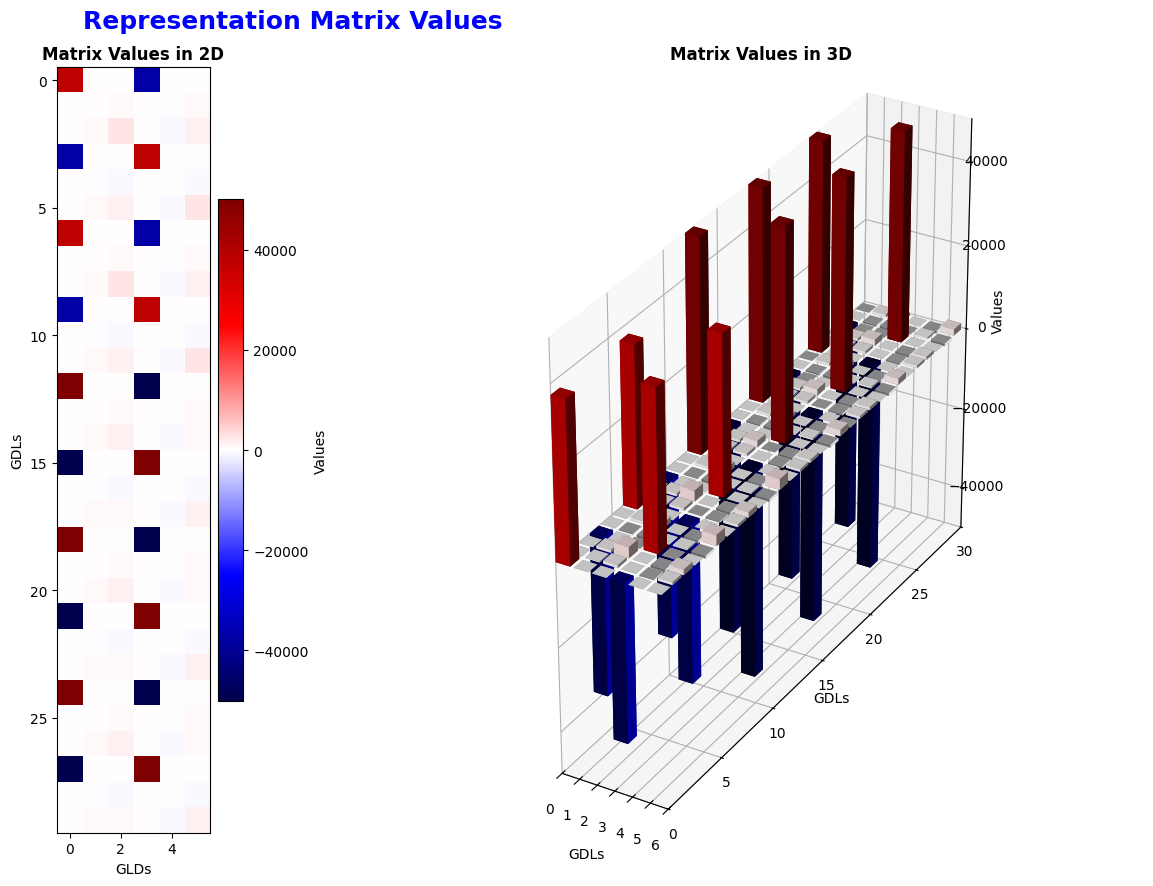

In [8]:
visualM = M_visual_2D_3D(K_all)
visualM.M_visual()

#### Example: Extraction of the Stiffness Matrix (local cordinates) of an Individual Element


In [9]:
if len(structure.elements) > 0:                                                                                     # Check if elements were added to the structure 
    n_elem = len(structure.elements)                                                                                # Get the number of elements in the structure
    print(f"\x1b[1;32m✅ The element stiffness matrices in local coordinates have been generated.\x1b[0m")          # Print success message with green color
    print(f"🧩 Number of MF elements in the structure: \x1b[1;34m{n_elem}\x1b[0m")                                  # Print number of elements with blue color
else:
    print(f"\x1b[1;31m🚫 Failed to generate element stiffness matrices in local coordinates.\x1b[0m")               # Print error message with red color              

✅ The element stiffness matrices in local coordinates have been generated.
🧩 Number of MF elements in the structure: 5


In [10]:
num_elem = 3                                                                                                        # Number of elements to display

if num_elem > len(structure.elements):                                                                              # Check if requested number of elements exceeds available
    print(f"\x1b[1;33m⚠️ Requested number of elements exceeds available.\x1b[0m")                                   # Display warning and show all available elements
else:
    elemL = structure.elements[num_elem-1].stiffness_matrix_MF_EI_AE_GAf_da_db()                                                  # Stiffness matrix of the second element      
    rows = pd.MultiIndex.from_tuples(
        [(f'Elem_{num_elem}', f'DOF_L_{d+1}') for e in range(1) for d in range(n_dof)],
        names=['Element', 'Local DOF']
    )      
    rows       
                                                                                
    elemL_df = pd.DataFrame(elemL, index=rows, columns=[f'DOF_{i}' for i in np.arange(1, elemL.shape[1] + 1)])      # Convert to DataFrame for better visualization
elemL_df.head(len(elemL_df))                                                                                        # Display the stiffness matrix of the second element                

DOF_1       DOF_2        DOF_3    DOF_4       DOF_5  \
Element Local DOF                                                          
Elem_3  DOF_L_1    50000.0    0.000000     0.000000 -50000.0    0.000000   
        DOF_L_2        0.0  343.218012   617.792422      0.0 -343.218012   
        DOF_L_3        0.0  617.792422  1487.026359      0.0 -617.792422   
        DOF_L_4   -50000.0    0.000000     0.000000  50000.0    0.000000   
        DOF_L_5        0.0 -343.218012  -617.792422      0.0  343.218012   
        DOF_L_6        0.0  617.792422   737.026359      0.0 -617.792422   

                         DOF_6  
Element Local DOF               
Elem_3  DOF_L_1       0.000000  
        DOF_L_2     617.792422  
        DOF_L_3     737.026359  
        DOF_L_4       0.000000  
        DOF_L_5    -617.792422  
        DOF_L_6    1487.026359

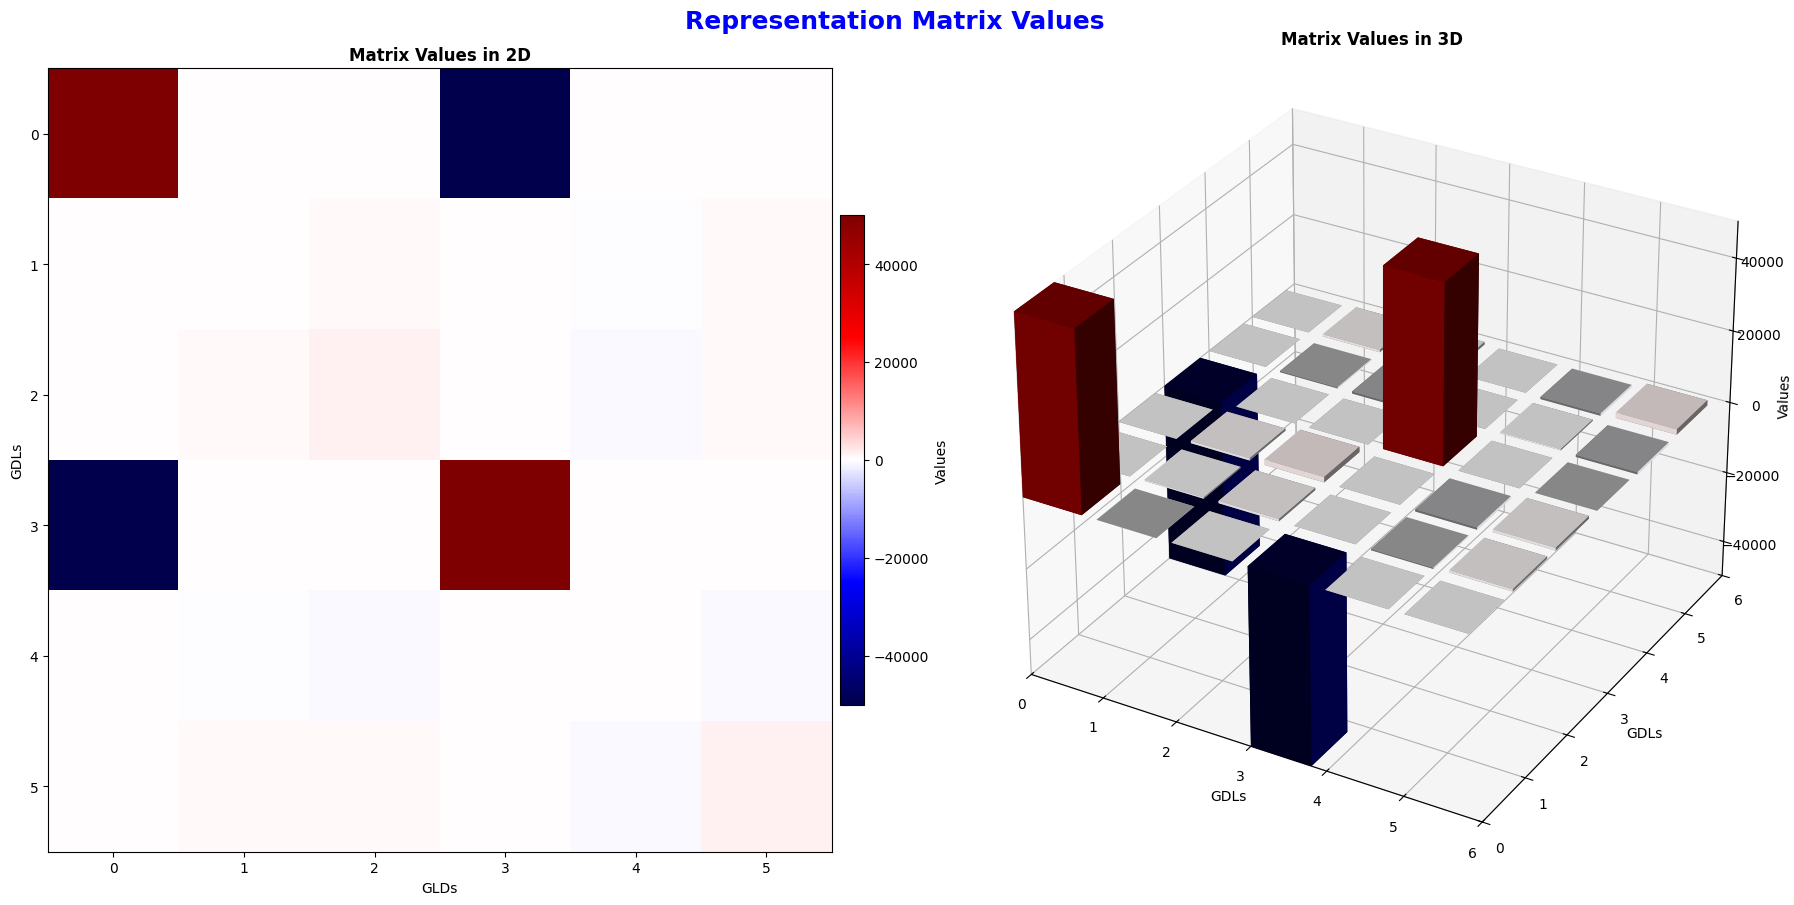

In [11]:
visualM = M_visual_2D_3D(elemL)
visualM.M_visual()

### Calculation of Matrix Transformations for MF Elements

In [12]:
# --- Stack Transformation matrices --------------------------------------------------------------------------------
T_all = structure.stacked_transformation_matrices()                                                                 # Stacked transformation matrix (6N x 6)

# --- Convert to DataFrame for visualization -----------------------------------------------------------------------
rows = pd.MultiIndex.from_tuples(
    [(f'Elem_{e+1}', f'DOF_L_G_{d+1}') for e in range(n_elem) for d in range(n_dof)],
    names=['Element', 'Local - Global DOF']
)

T_all_df = pd.DataFrame(T_all, index=rows, columns=[f'DOF_L_G_{i}' for i in np.arange(1, T_all.shape[1] + 1)])      # Convert to DataFrame for better visualization
T_all_df.head(len(T_all_df))                                                                                        # Display stacked matrices

DOF_L_G_1     DOF_L_G_2  DOF_L_G_3  \
Element Local - Global DOF                                          
Elem_1  DOF_L_G_1           1.000000e+00 -0.000000e+00        0.0   
        DOF_L_G_2           0.000000e+00  1.000000e+00        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_2  DOF_L_G_1           1.000000e+00 -0.000000e+00        0.0   
        DOF_L_G_2           0.000000e+00  1.000000e+00        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_3  DOF_L_G_1           6.123234e-17 -1.000000e+00        0.0   
        DOF_L_G_2           1.000000e+00  6.123234e-17        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_4  DOF_L_G_1          -1.836970e-16  1.000000e+00        0.0   
        DOF_L_G_2          -1.000000e+00 -1.836970e-16        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_5  DOF_L_G_1          -1.836970e-16  1.000000e+00        0.0   
        DOF_L_G_2          -1.000000e+00 -1.836970e-16        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   

                               DOF_L_G_4     DOF_L_G_5  DOF_L_G_6  
Element Local - Global DOF                                         
Elem_1  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           1.000000e+00 -0.000000e+00        0.0  
        DOF_L_G_5           0.000000e+00  1.000000e+00        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_2  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           1.000000e+00 -0.000000e+00        0.0  
        DOF_L_G_5           0.000000e+00  1.000000e+00        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_3  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           6.123234e-17 -1.000000e+00        0.0  
        DOF_L_G_5           1.000000e+00  6.123234e-17        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_4  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4          -1.836970e-16  1.000000e+00        0.0  
        DOF_L_G_5          -1.000000e+00 -1.836970e-16        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_5  DOF_L_G_1           0.000000e+00  0.000000e+00

#### Example: Extraction of the Transformation Matrix of an Individual Element

In [13]:
if len(structure.elements) > 0:                                                                                     # Check if elements were added to the structure 
    n_elem = len(structure.elements)                                                                                # Get the number of elements in the structure
    print(f"\x1b[1;32m✅ The element transformation matrices have been generated.\x1b[0m")                         # Print success message with green color
    print(f"🧩 Number of MF elements in the structure: \x1b[1;34m{n_elem}\x1b[0m")                                  # Print number of elements with blue color
else:
    print(f"\x1b[1;31m🚫 Failed to generate element transformation matrices.\x1b[0m")                               # Print error message with red color  

✅ The element transformation matrices have been generated.
🧩 Number of MF elements in the structure: 5


In [14]:
num_elem = 3                                                                                                        # Number of elements to display
if num_elem > len(structure.elements):                                                                              # Check if requested number of elements exceeds available
    print(f"\x1b[1;33m⚠️ Requested number of elements exceeds available.\x1b[0m")                                   # Display warning and show all available elements
else:
    elemT = structure.elements[num_elem-1].transformation_matrix_2D()                                               # Transformation matrix of the "n" element      
    rows = pd.MultiIndex.from_tuples(
        [(f'Elem_{num_elem}', f'DOF_L_G_{d+1}') for e in range(1) for d in range(n_dof)],
        names=['Element', 'Local - Global DOF']
    )      
    rows       
                                                                                
    elemT_df = pd.DataFrame(elemT, index=rows, columns=[f'DOF_L_G_{i}' for i in np.arange(1, elemT.shape[1] + 1)])  # Convert to DataFrame for better visualization
elemT_df.head(len(elemT_df))                                                                                        # Display the transformation matrix of the "n" element 

DOF_L_G_1     DOF_L_G_2  DOF_L_G_3  \
Element Local - Global DOF                                          
Elem_3  DOF_L_G_1           6.123234e-17 -1.000000e+00        0.0   
        DOF_L_G_2           1.000000e+00  6.123234e-17        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   

                               DOF_L_G_4     DOF_L_G_5  DOF_L_G_6  
Element Local - Global DOF                                         
Elem_3  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           6.123234e-17 -1.000000e+00        0.0  
        DOF_L_G_5           1.000000e+00  6.123234e-17        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0

### Stiffness Matrix in Global Coordinates

In [15]:
Keg_all = []                                                                                                        # Empty list to store global element stiffness matrices
for i in np.arange(0,n_elem,1):                                                                                     # Loop through each element
    Telem = structure.elements[i].transformation_matrix_2D()                                                    # Transformation matrix of element i
    Kelem = structure.elements[i].stiffness_matrix_MF_EI_AE_GAf_da_db()                                                         # Local stiffness matrix of element i
    Keg_all.append(Telem@Kelem@Telem.T)                                                                             # Transform local stiffness matrix to global coordinates

rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for global element matrices
    [
        (f'Elem_{e+1}', f'GDLg_{int(gdl)}')                                                                         # Element and global DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for gdl in Lee[e]                                                                                           # Loop through the placement vector of each element
    ],
    names=['Element', 'Placement Vector']                                                                           # Index level names
)

Keg_stack = np.vstack(Keg_all)                                                                                      # Stack all global element stiffness matrices
Keg_stack_df = pd.DataFrame(Keg_stack, index=rows,columns=[f'GLDg' for i in range(Global_dof)])                     # Convert stacked matrices to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Global Stiffness Matrices')                                                                                  # Print table title
print("=" * 120)                                                                                                    # Print table separator
Keg_stack_df.round(3)                                                                                               # Display rounded global element matrices

Global Stiffness Matrices


GLDg       GLDg      GLDg       GLDg  \
Element Placement Vector                                              
Elem_1  GDLg_1            37500.000      0.000     0.000 -37500.000   
        GDLg_2                0.000    208.963   626.888      0.000   
        GDLg_3                0.000    626.888  2513.478      0.000   
        GDLg_4           -37500.000      0.000     0.000  37500.000   
        GDLg_5                0.000   -208.963  -626.888      0.000   
        GDLg_6                0.000    626.888  1247.853      0.000   
Elem_2  GDLg_4            37500.000      0.000     0.000 -37500.000   
        GDLg_5                0.000    208.963   626.888      0.000   
        GDLg_6                0.000    626.888  2513.478      0.000   
        GDLg_7           -37500.000      0.000     0.000  37500.000   
        GDLg_8                0.000   -208.963  -626.888      0.000   
        GDLg_9                0.000    626.888  1247.853      0.000   
Elem_3  GDLg_10             343.218      0.000  -617.792   -343.218   
        GDLg_11               0.000  50000.000     0.000     -0.000   
        GDLg_12            -617.792      0.000  1487.026    617.792   
        GDLg_1             -343.218     -0.000   617.792    343.218   
        GDLg_2               -0.000 -50000.000    -0.000      0.000   
        GDLg_3             -617.792      0.000   737.026    617.792   
Elem_4  GDLg_4              343.218      0.000   617.792   -343.218   
        GDLg_5                0.000  50000.000    -0.000     -0.000   
        GDLg_6              617.792     -0.000  1487.026   -617.792   
        GDLg_13            -343.218     -0.000  -617.792    343.218   
        GDLg_14              -0.000 -50000.000     0.000      0.000   
        GDLg_15             617.792     -0.000   737.026   -617.792   
Elem_5  GDLg_7              343.218      0.000   617.792   -343.218   
        GDLg_8                0.000  50000.000    -0.000     -0.000   
        GDLg_9              617.792     -0.000  1487.026   -617.792   
        GDLg_16            -343.218     -0.000  -617.792    343.218   
        GDLg_17              -0.000 -50000.000     0.000      0.000   
        GDLg_18             617.792     -0.000   737.026   -617.792   

                               GLDg      GLDg  
Element Placement Vector                       
Elem_1  GDLg_1                0.000     0.000  
        GDLg_2             -208.963   626.888  
        GDLg_3             -626.888  1247.853  
        GDLg_4                0.000     0.000  
        GDLg_5              208.963  -626.888  
        GDLg_6             -626.888  2513.478  
Elem_2  GDLg_4                0.000     0.000  
        GDLg_5             -208.963   626.888  
        GDLg_6             -626.888  1247.853  
        GDLg_7                0.000     0.000  
        GDLg_8              208.963  -626.888  
        GDLg_9             -626.888  2513.478  
Elem_3  GDLg_10              -0.000  -617.792  
        GDLg_11          -50000.000     0.000  
        GDLg_12              -0.000   737.026  
        GDLg_1                0.000   617.792  
        GDLg_2            50000.000    -0.000  
        GDLg_3               -0.000  1487.026  
Elem_4  GDLg_4               -0.000   617.792  
        GDLg_5           -50000.000    -0.000  
        GDLg_6                0.000   737.026  
        GDLg_13               0.000  -617.792  
        GDLg_14           50000.000     0.000  
        GDLg_15               0.000  1487.026  
Elem_5  GDLg_7               -0.000   617.792  
        GDLg_8           -50000.000    -0.000  
        GDLg_9                0.000   737.026  
        GDLg_16               0.000  -617.792  
        GDLg_17           50000.000     0.000  
        GDLg_18               0.000  1487.026

### Stiffness Matrix of the Structure.

#### Initialize Stiffness Matrix of the Structure

In [16]:
S = np.zeros((nglt, nglt))                                                                                          # Initialize global Structure stiffness matrix
rowsS = pd.Index(f'GDLg_{i+1}' for i in range(nglt))                                                                # Global DOF labels
S_df = pd.DataFrame(S,index= rowsS, columns=[f'GDLg_{i+1}' for i in range(nglt)])                                   # Convert global stiffness matrix to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Initialize global Structure stiffness matrix')                                                               # Print table title
print("=" * 120)                                                                                                    # Print table separator
S_df.round(3)         

Initialize global Structure stiffness matrix


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5,GDLg_6,GDLg_7,GDLg_8,GDLg_9,GDLg_10,GDLg_11,GDLg_12,GDLg_13,GDLg_14,GDLg_15,GDLg_16,GDLg_17,GDLg_18
GDLg_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Assemble Stiffness Matrices of the Structure

In [17]:
for e in range(n_elem):                                                                                             # Loop through each element
    lee = Lee[e]                                                                                                    # Placement vector of element e
    Ke = Keg_all[e]                                                                                                 # Global stiffness matrix of element e
    S_assambler = Assembler(lee = lee, K = Ke, S = S, nglt= nglt)                                                   # Create assembler object for element e
    S = S_assambler.assambler_due_lee()                                                                             # Assemble element stiffness into the global matrix
S_df = pd.DataFrame(S,index= rowsS, columns=[f'GDLg_{i+1}' for i in range(nglt)])                                   # Convert assembled stiffness matrix to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Global Structure Stiffness Matrix')                                                                          # Print table title
print("=" * 120)                                                                                                    # Print table separator
S_df.round(3)                                                                                                       # Display rounded assembled stiffness matrix

Global Structure Stiffness Matrix


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5,GDLg_6,GDLg_7,GDLg_8,GDLg_9,GDLg_10,GDLg_11,GDLg_12,GDLg_13,GDLg_14,GDLg_15,GDLg_16,GDLg_17,GDLg_18
GDLg_1,37843.218,0.000,617.792,-37500.000,0.000,0.000,0.000,0.000,0.000,-343.218,-0.0,617.792,0.000,0.0,0.000,0.000,0.0,0.000
GDLg_2,0.000,50208.963,626.888,0.000,-208.963,626.888,0.000,0.000,0.000,-0.000,-50000.0,-0.000,0.000,0.0,0.000,0.000,0.0,0.000
GDLg_3,617.792,626.888,4000.504,0.000,-626.888,1247.853,0.000,0.000,0.000,-617.792,0.0,737.026,0.000,0.0,0.000,0.000,0.0,0.000
GDLg_4,-37500.000,0.000,0.000,75343.218,0.000,617.792,-37500.000,0.000,0.000,0.000,0.0,0.000,-343.218,-0.0,617.792,0.000,0.0,0.000
GDLg_5,0.000,-208.963,-626.888,0.000,50417.926,-0.000,0.000,-208.963,626.888,0.000,0.0,0.000,-0.000,-50000.0,-0.000,0.000,0.0,0.000
GDLg_6,0.000,626.888,1247.853,617.792,-0.000,6513.982,0.000,-626.888,1247.853,0.000,0.0,0.000,-617.792,0.0,737.026,0.000,0.0,0.000
GDLg_7,0.000,0.000,0.000,-37500.000,0.000,0.000,37843.218,0.000,617.792,0.000,0.0,0.000,0.000,0.0,0.000,-343.218,-0.0,617.792
GDLg_8,0.000,0.000,0.000,0.000,-208.963,-626.888,0.000,50208.963,-626.888,0.000,0.0,0.000,0.000,0.0,0.000,-0.000,-50000.0,-0.000
GDLg_9,0.000,0.000,0.000,0.000,626.888,1247.853,617.792,-626.888,4000.504,0.000,0.0,0.000,0.000,0.0,0.000,-617.792,0.0,737.026
GDLg_10,-343.218,-0.000,-617.792,0.000,0.000,0.000,0.000,0.000,0.000,343.218,0.0,-617.792,0.000,0.0,0.000,0.000,0.0,0.000


#### Vizualizer "S"

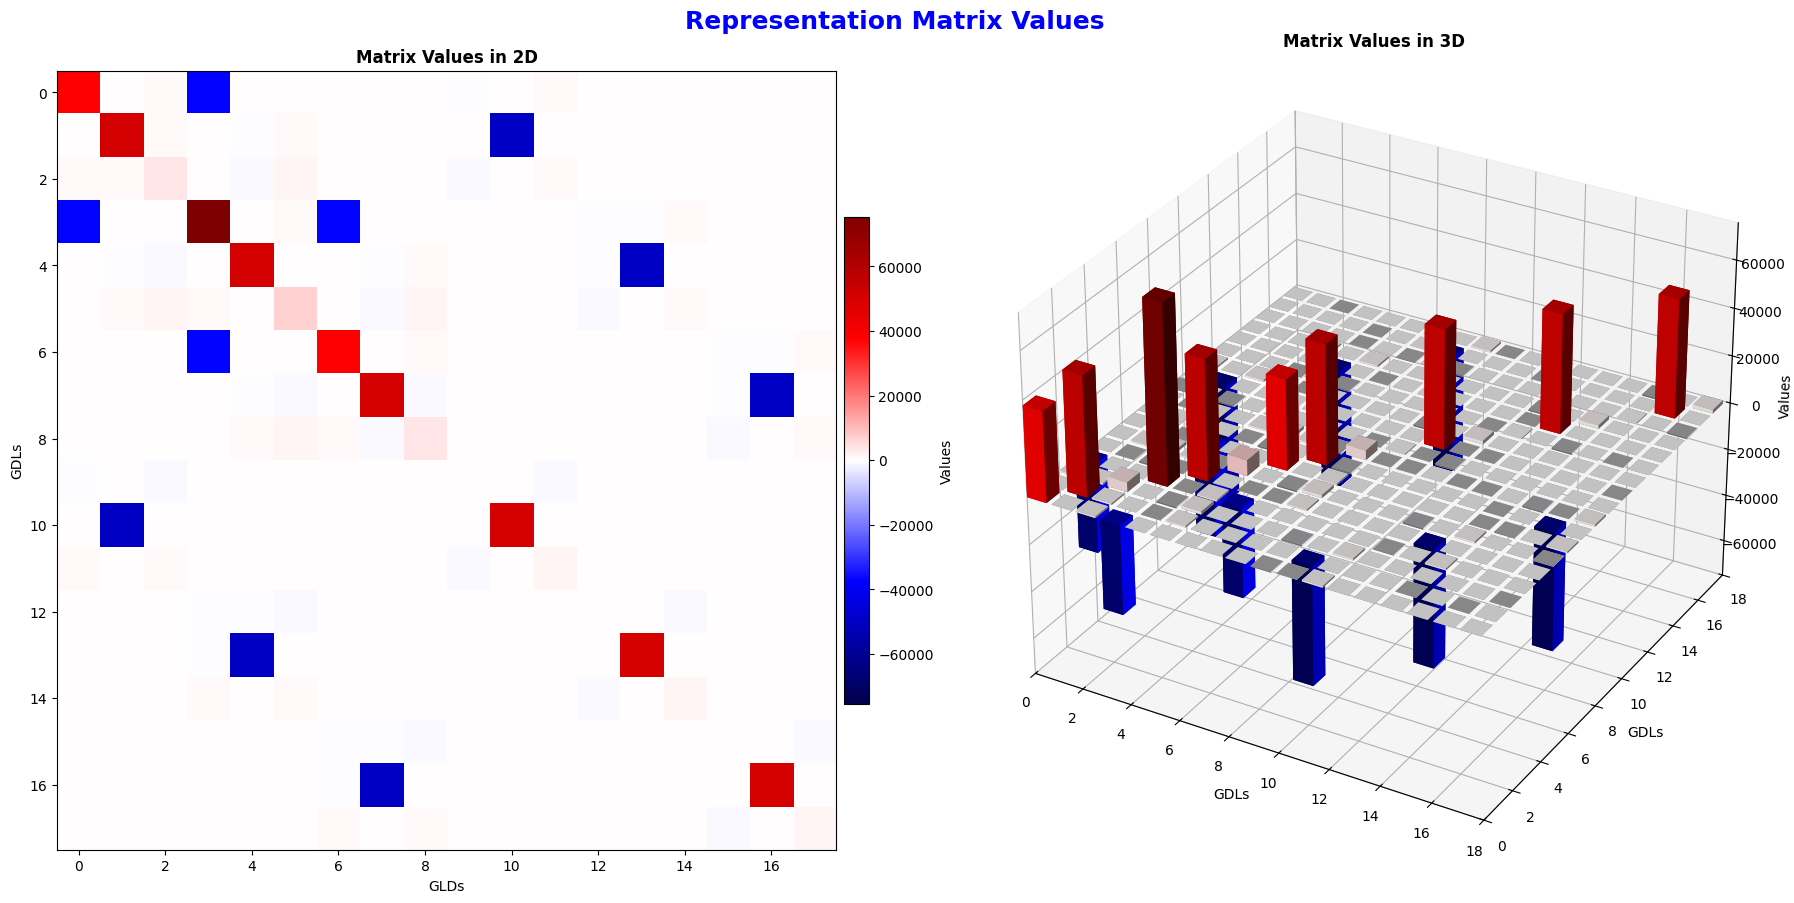

In [18]:
S_vizual = M_visual_2D_3D(S)
S_vizual.M_visual()


#### SLL

In [19]:
SLL = S[0:gdl,0:gdl]                                                                                                # Extract stiffness submatrix for free global DOF
SLL_df = pd.DataFrame(SLL,index= rowsS[0:gdl], columns=[f'GDLg_{i+1}' for i in range(gdl)])                         # Convert stiffness matrix (SLL) to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Global Structure Stiffness Matrix, SLL')                                                                     # Print table title
print("=" * 120)                                                                                                    # Print table separator
SLL_df.round(3)                                                                                                     # Display rounded SLL stiffness matrix

Global Structure Stiffness Matrix, SLL


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5,GDLg_6,GDLg_7,GDLg_8,GDLg_9
GDLg_1,37843.218,0.000,617.792,-37500.000,0.000,0.000,0.000,0.000,0.000
GDLg_2,0.000,50208.963,626.888,0.000,-208.963,626.888,0.000,0.000,0.000
GDLg_3,617.792,626.888,4000.504,0.000,-626.888,1247.853,0.000,0.000,0.000
GDLg_4,-37500.000,0.000,0.000,75343.218,0.000,617.792,-37500.000,0.000,0.000
GDLg_5,0.000,-208.963,-626.888,0.000,50417.926,-0.000,0.000,-208.963,626.888
GDLg_6,0.000,626.888,1247.853,617.792,-0.000,6513.982,0.000,-626.888,1247.853
GDLg_7,0.000,0.000,0.000,-37500.000,0.000,0.000,37843.218,0.000,617.792
GDLg_8,0.000,0.000,0.000,0.000,-208.963,-626.888,0.000,50208.963,-626.888
GDLg_9,0.000,0.000,0.000,0.000,626.888,1247.853,617.792,-626.888,4000.504


#### Vizualizer "SLL"

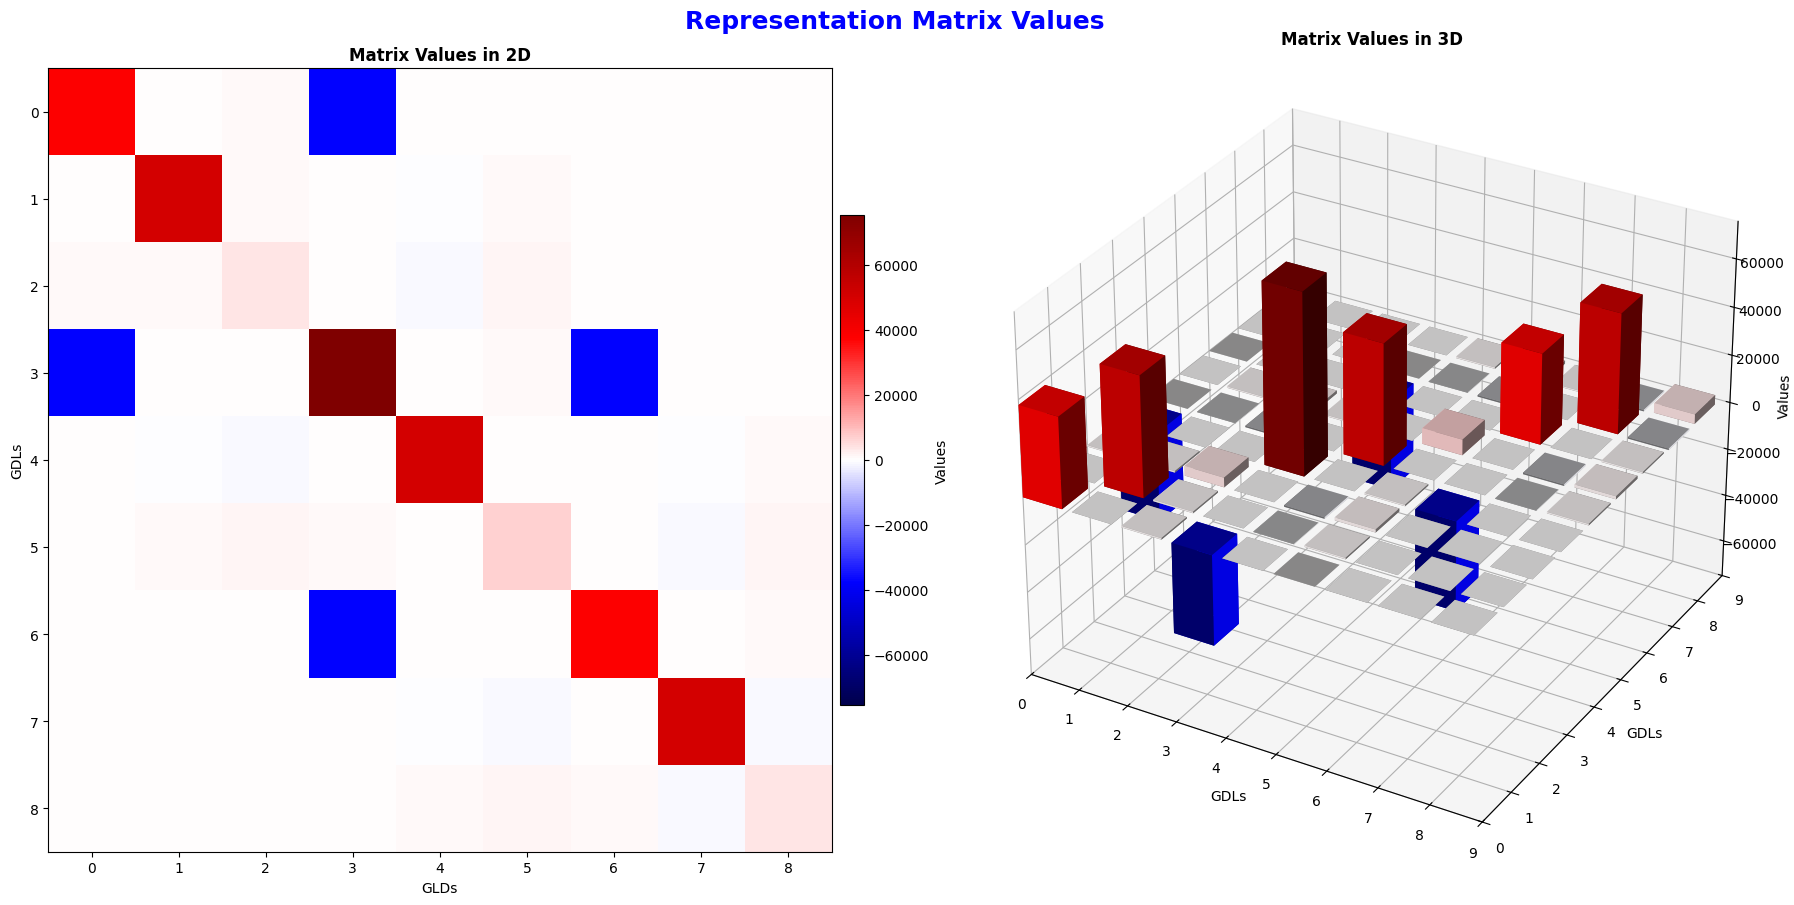

In [20]:
SLL3d = M_visual_2D_3D(SLL)                                                                                         # Create 3D visualization object for the reduced stiffness matrix
SLL3d.M_visual()                                                                                                    # Display reduced stiffness matrix as a 3D plot

### Calculation of Global Displacement.

#### Load Nodal Vector

In [21]:
P_df = pd.DataFrame(P,index= rowsS[0:gdl], columns=['Loads'])                                                       # Convert load vector to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Load Nodal Vector [P]')                                                                                      # Print table title
print("=" * 120)                                                                                                    # Print table separator
P_df.round(3)                                                                                                       # Display rounded load vector

Load Nodal Vector [P]


,Loads
GDLg_1,50.0
GDLg_2,-5.0
GDLg_3,0.0
GDLg_4,0.0
GDLg_5,-10.0
GDLg_6,0.0
GDLg_7,0.0
GDLg_8,-5.0
GDLg_9,0.0


#### Global Displacement Vector

In [22]:
SLL_inv = np.linalg.inv(SLL)                                                                                        # Compute inverse of the reduced stiffness matrix
delta_g = SLL_inv@P                                                                                                 # Solve global free DOF displacements

delta_g_full = np.vstack((delta_g, np.zeros((nglt-gdl, 1))))

delta_g_df = pd.DataFrame(delta_g_full, index = rowsS[:nglt],columns= ['delta_GDL_g [m]'])                          # Convert displacement vector to DataFrame

print("=" * 120)                                                                                                    # Print table separator
print('Global Displacements')                                                                                       # Print table title
print("=" * 120)                                                                                                    # Print table separator
delta_g_df.round(10)                                                                                                # Display rounded displacement vector
delta_g_df                                                                                                          # Display global displacement vector

Global Displacements


,delta_GDL_g [m]
GDLg_1,0.061081
GDLg_2,0.000039
GDLg_3,-0.008709
GDLg_4,0.060163
GDLg_5,-0.000202
GDLg_6,-0.002441
GDLg_7,0.059756
GDLg_8,-0.000237
GDLg_9,-0.008472
GDLg_10,0.000000


#### Plot Global Displacement

elem_1, node i = 1 to node j = 2
elem_2, node i = 2 to node j = 3
elem_3, node i = 4 to node j = 1
elem_4, node i = 2 to node j = 5
elem_5, node i = 3 to node j = 6
Displacement range: 0.0000 to 6.1218 cm


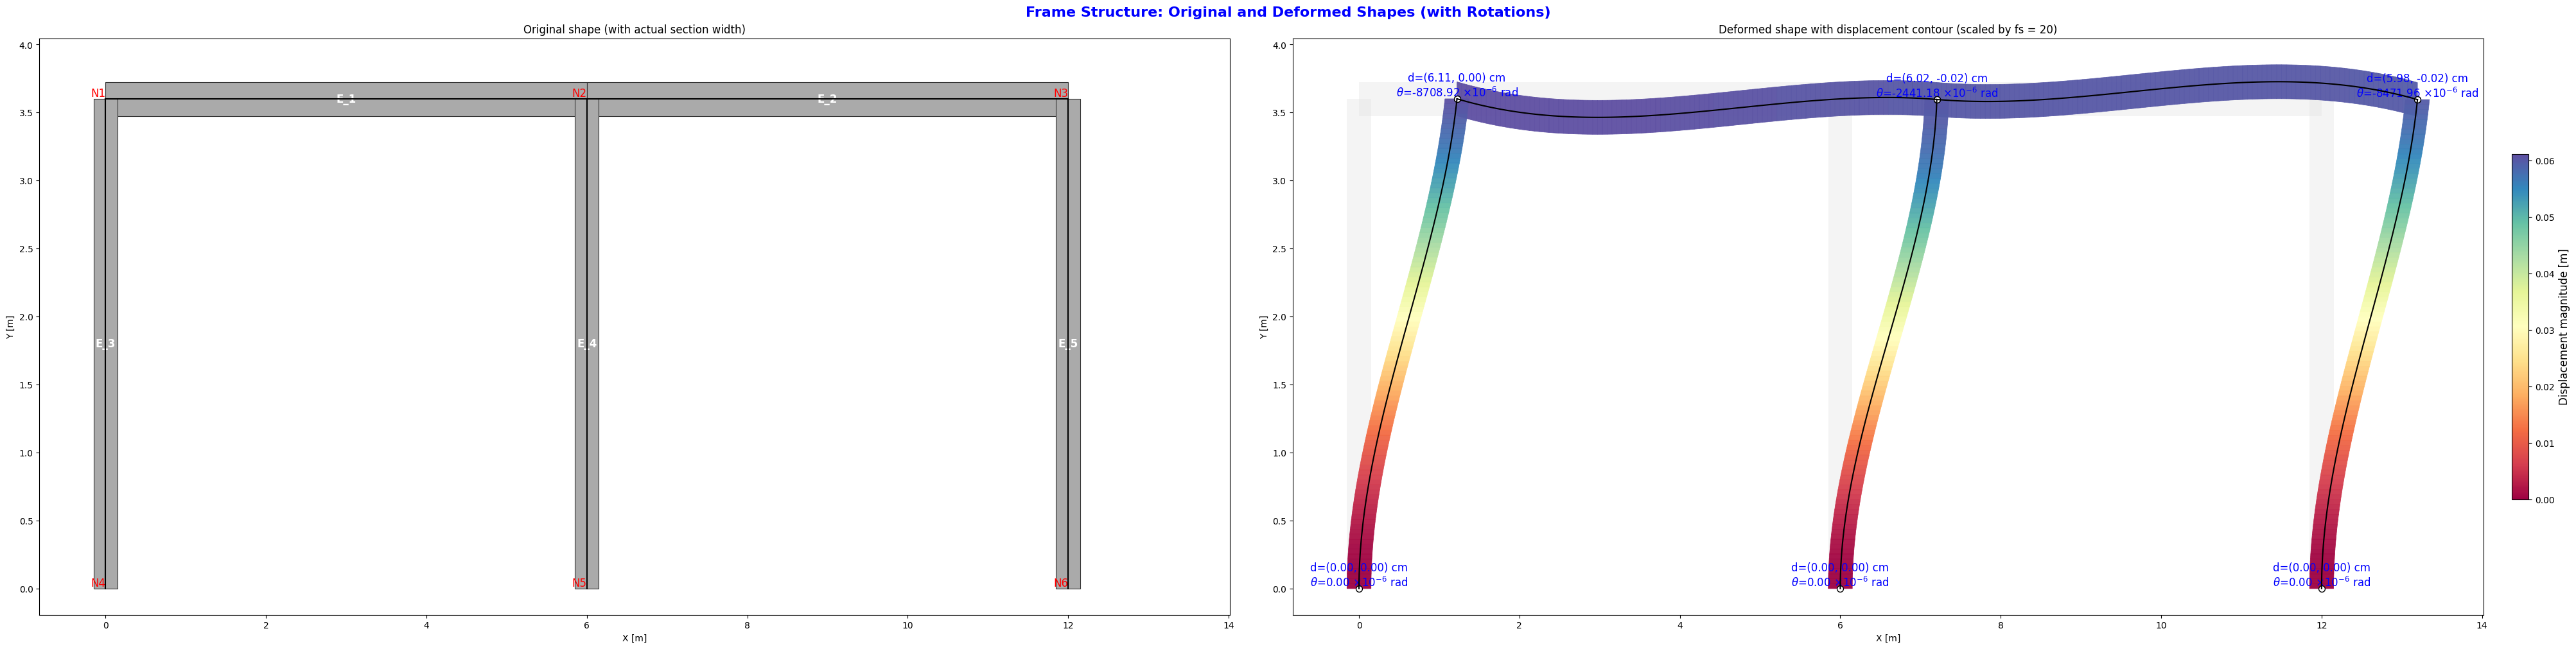

In [33]:
delta_g_values = np.asarray(delta_g_full, dtype=float).ravel()

# --- Node coordinate table: (x, y, ux, uy, rotation) -----------------
CoordNode = np.array([
    [0, Lc, delta_g_values[0], delta_g_values[1],  delta_g_values[2]],
    [Lv, Lc, delta_g_values[3], delta_g_values[4],  delta_g_values[5]],
    [2*Lv, Lc, delta_g_values[6], delta_g_values[7],  delta_g_values[8]],
    [0, 0, delta_g_values[9], delta_g_values[10], delta_g_values[11]],
    [Lv, 0, delta_g_values[12], delta_g_values[13], delta_g_values[14]],
    [2*Lv, 0, delta_g_values[15], delta_g_values[16], delta_g_values[17]],
])

# List of Colors #
'coolwarm'
'jet'
'turbo'
'viridis'
'plasma'
'inferno'
'magma'
'cividis'
'RdYlBu'
'RdYlGn'
'seismic'
'bwr'
'PiYG'
'PRGn'
'Spectral'

plotDisp = PlotGlobalDislplacemet(fs = 20,n_sub= 100,Lee_Nodos= Lee_Nodos, delta_g_full= delta_g_full,CoordNode= CoordNode, hv = bv, bc = bc, color='Spectral')
plotDisp.PlotGD_RMF()

#### Global Displacement for each Element

In [25]:
delta_g_full = np.vstack((delta_g, np.zeros((nglt-gdl, 1))))
Delta_g_elem = []

LeeE = Lee - 1

for e in np.arange(0,len(Lee),1):
    Delta_g_elem.append(delta_g_full[LeeE[e]])

Delta_g_elem = np.vstack(Delta_g_elem)


rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for global element matrices
    [
        (f'Elem_{e+1}', f'GDLg_{int(gdl)}')                                                                         # Element and global DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for gdl in Lee[e]                                                                                           # Loop through the placement vector of each element
    ],
    names=['Element', 'Placement Vector']                                                                           # Index level names
)


Delta_g_elem_df = pd.DataFrame(Delta_g_elem,index = rows,columns= ['Global Displacement for each Element'])
Delta_g_elem_df.round(6)

Global Displacement for each Element
Element Placement Vector                                      
Elem_1  GDLg_1                                        0.061081
        GDLg_2                                        0.000039
        GDLg_3                                       -0.008709
        GDLg_4                                        0.060163
        GDLg_5                                       -0.000202
        GDLg_6                                       -0.002441
Elem_2  GDLg_4                                        0.060163
        GDLg_5                                       -0.000202
        GDLg_6                                       -0.002441
        GDLg_7                                        0.059756
        GDLg_8                                       -0.000237
        GDLg_9                                       -0.008472
Elem_3  GDLg_10                                       0.000000
        GDLg_11                                       0.000000
        GDLg_12                                       0.000000
        GDLg_1                                        0.061081
        GDLg_2                                        0.000039
        GDLg_3                                       -0.008709
Elem_4  GDLg_4                                        0.060163
        GDLg_5                                       -0.000202
        GDLg_6                                       -0.002441
        GDLg_13                                       0.000000
        GDLg_14                                       0.000000
        GDLg_15                                       0.000000
Elem_5  GDLg_7                                        0.059756
        GDLg_8                                       -0.000237
        GDLg_9                                       -0.008472
        GDLg_16                                       0.000000
        GDLg_17                                       0.000000
        GDLg_18                                       0.000000

#### Local Displacement and Action Member in Local Cordinates for each Element

In [26]:
Delta_L_elem_all = []                                                                                              # Empty list to store local displacement vectors
New_L_elem = []                                                                                                    # Empty list to store current element lengths
New_L_elem_rows = []                                                                                               # Current lengths repeated for each local DOF row
MENSAJE = []
MENSAJE_rows = []
CA = []
CA_rows = []

AmL = []

MENSAJE2 = []
MENSAJE2_rows = []

for e in np.arange(0, n_elem, 1):                                                                                   # Loop through each element
# for e in np.arange(2):
    Telem = structure.elements[e].transformation_matrix_2D()                                                        # Local-to-global transformation matrix
    Delta_g_elem_e = delta_g_full[LeeE[e]]                                                                          # Global displacement vector of element e
    Delta_L_elem_e = Telem.T @ Delta_g_elem_e                                                                       # Transform global displacements to local coordinates
    
    #-------- Action Members --------
    aml = structure.elements[e].stiffness_matrix_MF_EI_AE_GAf_da_db() @ Delta_L_elem_e

    Delta_L_elem_all.append(Delta_L_elem_e)                                                                         # Store local displacement vector
    
    AmL.append(aml)

Delta_L_elem_all = np.vstack(Delta_L_elem_all)                                                                      # Stack local displacement vectors
AmL = np.vstack(AmL)


rows_L = pd.MultiIndex.from_tuples(                                                                                 # Create hierarchical index for local displacement vectors
    [
        (f'Elem_{e+1}', f'DOF_L_{d+1}')                                                                             # Element and local DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for d in range(local_dof)                                                                                   # Loop through local DOF
    ],
    names=['Element', 'Local DOF']                                                                                  # Index level names
)

Delta_L_elem_all_df = pd.DataFrame(                                                                                 # Convert local displacements and lengths to DataFrame
    {
        'Local Displacement for each Element [m]': Delta_L_elem_all.ravel(),
        'Action Members [T]': AmL.ravel(),
   
    },
    index=rows_L
)
Delta_L_elem_all_df.round(6)

Local Displacement for each Element [m]  Action Members [T]
Element Local DOF                                                             
Elem_1  DOF_L_1                                   0.061081           34.416255
        DOF_L_2                                   0.000039           -6.939529
        DOF_L_3                                  -0.008709          -24.784895
        DOF_L_4                                   0.060163          -34.416255
        DOF_L_5                                  -0.000202            6.939529
        DOF_L_6                                  -0.002441          -16.852281
Elem_2  DOF_L_1                                   0.060163           15.275340
        DOF_L_2                                  -0.000202           -6.834092
        DOF_L_3                                  -0.002441          -16.685925
        DOF_L_4                                   0.059756          -15.275340
        DOF_L_5                                  -0.000237            6.834092
        DOF_L_6                                  -0.008472          -24.318628
Elem_3  DOF_L_1                                   0.000000           -1.939529
        DOF_L_2                                   0.000000           15.583745
        DOF_L_3                                   0.000000           31.316586
        DOF_L_4                                   0.000039            1.939529
        DOF_L_5                                  -0.061081          -15.583745
        DOF_L_6                                  -0.008709           24.784895
Elem_4  DOF_L_1                                   0.000202           10.105437
        DOF_L_2                                   0.060163           19.140916
        DOF_L_3                                  -0.002441           33.538206
        DOF_L_4                                   0.000000          -10.105437
        DOF_L_5                                   0.000000          -19.140916
        DOF_L_6                                   0.000000           35.369090
Elem_5  DOF_L_1                                   0.000237           11.834092
        DOF_L_2                                   0.059756           15.275340
        DOF_L_3                                  -0.008472           24.318628
        DOF_L_4                                   0.000000          -11.834092
        DOF_L_5                                   0.000000          -15.275340
        DOF_L_6                                   0.000000           30.672595

#### Reactions

In [27]:
React_gdl_g = np.zeros(nglt-gdl)
SRL_SRR = S[gdl:]

React_gdl_g = SRL_SRR @ delta_g_full

React_gdl_g_df = pd.DataFrame(React_gdl_g,index = rowsS[gdl:nglt], columns= ['Reactions [T]'])
React_gdl_g_df.round(3)

,Reactions [T]
GDLg_10,-15.584
GDLg_11,-1.940
GDLg_12,31.317
GDLg_13,-19.141
GDLg_14,10.105
GDLg_15,35.369
GDLg_16,-15.275
GDLg_17,11.834
GDLg_18,30.673
